In [1]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from dataclasses import dataclass 
import math
import os

from transformers import AutoTokenizer

/home/pensativo/code/vision-ai-guide/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class LayerNormalization(nn.Module):
    def __init__(self, model_dim):
        super().__init__()
        self.model_dim = model_dim
        self.gamma = nn.Parameter(torch.ones(self.model_dim))
        self.beta = nn.Parameter(torch.zeros(self.model_dim))
        self.eps = 1e-5

    def forward(self, x):
        B, T, D = x.shape
        x_centered = x - torch.mean(x, dim=-1, keepdim=True)
        x_var = torch.mean(x_centered**2, dim=-1, keepdim=True)
        output = x_centered/torch.sqrt(x_var + self.eps)
        return self.gamma * output + self.beta 
    
class Linear(nn.Module):
    def __init__(self, in_dim, out_dim, bias=False):
        super().__init__()

        #define w parameter, no bias for now
        #divide by math.sqrt(in_dim) to avoid bad parameter initialization
        self.W = nn.Parameter(torch.randn(in_dim, out_dim)/ math.sqrt(in_dim))
    
    def forward(self, x):
        return torch.matmul(x, self.W)

class GLU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        B, T, D1 = x.shape
        N = D1 // 2
        l_proj1 =  x[:,:, :N]
        l_proj2 = x[:, :, N:]

        return l_proj1 * torch.sigmoid(l_proj2)

def SoftMax(x, dim):

    #numerically stable softmax
    x_max, _ = torch.max(x, dim=dim, keepdim=True)       #values, indices
    x_scaled = x - x_max
    num = torch.exp(x_scaled)
    den = torch.sum(num, dim=dim, keepdim=True)
    return num / den

def CrossEntropy(logits, targets, ignore_index=-100):

    #skip logits with ignore targets in the input
    mask = targets != ignore_index
    logits = logits[mask]                                                                                                            
    targets = targets[mask]

    log_probs = logits - torch.logsumexp(logits, dim=-1, keepdim=True)
    predictions = log_probs[torch.arange(len(targets), device=logits.device), targets]
    loss = -predictions.mean()
    
    return loss

In [3]:
class MultiHeadAttention(nn.Module):
    def __init__(self, model_dim, num_heads, device):
        super().__init__()
        self.model_dim = model_dim
        self.head_dim = model_dim // num_heads
        self.num_heads = num_heads
        self.device = device

        self.q_proj = Linear(self.model_dim, self.model_dim, bias=False)
        self.k_proj = Linear(self.model_dim, self.model_dim, bias=False)
        self.v_proj = Linear(self.model_dim, self.model_dim, bias=False)

        self.o_proj = Linear(self.model_dim, self.model_dim, bias=False)
    

    def forward(self, x, attention_mask=None, causal=False):
        B, T, D = x.shape
        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)

        q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        score = torch.matmul(q, k.transpose(-2, -1)) #B, H, T, T
        score = score/math.sqrt(self.head_dim)

        if causal:
            causal_mask = torch.tril(torch.ones(T, T)).to(self.device)
            score = score.masked_fill(causal_mask==0, float('-inf'))
        
        if attention_mask is not None:
            key_mask = attention_mask[:, None, None, :].bool()   # [B,1,1,T]
            score = score.masked_fill(~key_mask, float("-inf"))

            
        attn_score = SoftMax(score, dim=-1) #B, H, T, T
        attention = torch.matmul(attn_score, v) #B, H, T, D_h
        attention = attention.transpose(1, 2).contiguous().view(B, T, D) #B, T, D

        return self.o_proj(attention) #B, T, D

class LayerNormalization(nn.Module):
    def __init__(self, model_dim):
        super().__init__()
        self.model_dim = model_dim
        self.gamma = nn.Parameter(torch.ones(self.model_dim))
        self.beta = nn.Parameter(torch.zeros(self.model_dim))
        self.eps = 1e-5

    def forward(self, x):
        B, T, D = x.shape
        x_centered = x - torch.mean(x, dim=-1, keepdim=True)
        x_var = torch.mean(x_centered**2, dim=-1, keepdim=True)
        output = x_centered/torch.sqrt(x_var + self.eps)
        return self.gamma * output + self.beta 

In [4]:
class TransformerBlock(nn.Module):
    def __init__(self, model_dim, num_heads, device) :
        super().__init__()

        self.MHSA = MultiHeadAttention(model_dim, num_heads, device)
        self.layernorm1 = LayerNormalization(model_dim)
        self.layernorm2 = LayerNormalization(model_dim)

        self.FFN = nn.Sequential(   
                        Linear(model_dim, 4*model_dim, bias=False),
                        GLU(),
                        Linear(2*model_dim, model_dim, bias=False)
                    )
    def forward(self, x, attention_mask=None, causal=True):
        x1 = x + self.MHSA(self.layernorm1(x), attention_mask=attention_mask, causal=causal)
        x2 = x1 + self.FFN(self.layernorm2(x1))
        return x2

In [5]:
class GPT(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        self.model_dim = cfg.model_dim
        self.num_heads = cfg.num_heads
        self.num_blocks = cfg.num_blocks
        self.vocab_size = cfg.vocab_size
        self.max_seq_len = cfg.max_seq_length
        self.device = cfg.device

        #transformer blocks 
        self.num_blocks = self.num_blocks
        self.blocks = nn.ModuleList([TransformerBlock(self.model_dim, self.num_heads, self.device) for _ in range(self.num_blocks)])
        self.logit_proj = Linear(self.model_dim, cfg.vocab_size, bias=False)

        #token and position embeddings
        self.token_embeddings = nn.Embedding(self.vocab_size, self.model_dim)
        self.pos_emb = nn.Embedding(self.max_seq_len, self.model_dim)


    def input_embeddings(self, x):
        B, T = x.shape
        x1 = self.token_embeddings(x) #B, T -> #B, T, D
        pos_emb = self.pos_emb(torch.arange(T, device=self.device))
        x = x1 + pos_emb #B, T, D + (T, D)->B, T, D
        return x

    def forward(self, x=None, targets=None, input_embeds=None, attention_mask=None, causal=True):

        if x is None and input_embeds is None:
            raise ValueError("Either x or input_embeds must be provided")
        
        if input_embeds is not None:
            x = input_embeds

        else:
            if x is not None:
                x = self.input_embeddings(x)
           
        for i in range(self.num_blocks):
            x = self.blocks[i](x, attention_mask, causal)
        
        logits = self.logit_proj(x) #B, T, V

        B, T1, V = logits.shape
        logits = logits.view(B*T1, V)

        loss = 0.0
        if targets is not None:
            targets = targets.reshape(B*T1)
            loss = CrossEntropy(logits, targets)
       
        return logits, loss

In [6]:
class ViT(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        self.model_dim = cfg.model_dim
        self.num_heads = cfg.num_heads
        self.num_blocks = cfg.num_blocks
        self.num_patches = cfg.num_patches # H//P * W //P
        self.device = cfg.device
        self.patch_size = cfg.patch_size #P
        self.patch_dim = cfg.patch_dim   #C*P*P
        self.num_classes = cfg.num_classes

        #transformer blocks (non-causal for ViT — every token attends to every other)
        self.num_blocks = self.num_blocks
        self.blocks = nn.ModuleList([TransformerBlock(self.model_dim, self.num_heads, self.device) for _ in range(self.num_blocks)])
        self.logit_proj = Linear(self.model_dim, cfg.num_classes, bias=False)

        #token and position embeddings
        self.cls_token = nn.Parameter(torch.randn(1, 1, self.model_dim))
        self.x_proj = Linear(self.patch_dim, self.model_dim)
        self.pos_emb = nn.Embedding(self.num_patches+1, self.model_dim)

    
    def img_to_patch(self, x):
        B, C, H, W = x.shape
    
        P = self.patch_size

        x = x.unfold(dimension=2, size=P, step=P)
        x = x.unfold(dimension=3, size=P, step=P)     #B, C, H/P, W/P, P, P
        x = x.permute(0, 2, 3, 1, 4, 5)         #B, H/P, W/P, C, P, P

        #reshape to [B, T, D]
        num_patches = H//P * W //P
        patch_dim = C*P*P
        x = x.reshape(B, num_patches, C, P, P).reshape(B, num_patches, patch_dim) #B, T, D
        return self.x_proj(x)
        
    def get_contextualized_embeddings(self, x, attention_mask=None, causal=False):
        B, C, H, W = x.shape
        x = self.img_to_patch(x)
        cls_token1 = self.cls_token.expand(B, 1, self.model_dim)
        x = torch.cat([cls_token1, x], dim=1)

        #add position embeddings 
        pos_emb = self.pos_emb(torch.arange(self.num_patches+1, device=x.device)) #T, D
        x = x + pos_emb

        #transformer blocks 
        for i in range(self.num_blocks):
            x = self.blocks[i](x ,attention_mask, causal)

        return x

    def encode(self, x):
        x = self.get_contextualized_embeddings(x)
        return x[:, 1:, :]
        
    def forward(self, x, targets=None, attention_mask=None, causal=False):
       
        x = self.get_contextualized_embeddings(x ,attention_mask, causal)
        
        cls_logit = x[:, 0, :]  #B, D
        logits = self.logit_proj(cls_logit) #B, C

        loss = 0.0
        if targets != None:
            loss = CrossEntropy(logits, targets)

        return logits, loss

In [7]:
class VLM(nn.Module):
    def __init__(self, cfg):

        super().__init__()

        self.vision_encoder = cfg.vision_encoder
        self.LLM = cfg.LLM

        self.model_dim = cfg.model_dim
        self.vision_model_dim = cfg.vision_model_dim
        self.vision_proj = Linear(cfg.vision_model_dim, cfg.model_dim)

        #freeze vision encoder parameters
        for param in self.vision_encoder.parameters():
            param.requires_grad = False

    def generate(self, x_img, x_text, attention_mask, max_new_tokens, eos_token_id):                                                                                                      
      # Encode image once                                                                                                                                                               
        img_embeddings = self.vision_proj(self.vision_encoder.encode(x_img))                                                                                                              
        text_embeddings = self.LLM.token_embeddings(x_text)                                                                                                                               
        llm_embeddings = torch.cat([img_embeddings, text_embeddings], dim=1)                                                                                                              
                  
        B, N, _ = img_embeddings.shape                                                                                                                                                    
        device = llm_embeddings.device
                                                                                                                                                                                        
        # Add positional embeddings for the initial prompt
        pos_ids = torch.arange(llm_embeddings.shape[1], device=device)
        llm_embeddings = llm_embeddings + self.LLM.pos_emb(pos_ids)                                                                                                                       
                                                                                                                                                                                        
        # Extend attention mask to cover image tokens                                                                                                                                     
        if attention_mask is not None:                                                                                                                                                    
            img_mask = torch.ones((B, N), dtype=attention_mask.dtype, device=device)
            attention_mask = torch.cat([img_mask, attention_mask], dim=1)                                                                                                                 
   
        generated_ids_list = []                                                                                                                                                           
        finished = torch.zeros(B, dtype=torch.bool, device=device)
                                                                                                                                                                                        
        for _ in range(max_new_tokens):                                                                                                                                                   
            logits, _ = self.LLM(
                input_embeds=llm_embeddings,                                                                                                                                              
                targets=None,
                attention_mask=attention_mask,
                causal=True,
            )                                                                                                                                                                             
   
            B, T_cur, _ = llm_embeddings.shape
            logits = logits.view(B, T_cur, self.LLM.vocab_size)

            # Sample next token from last position                                                                                                                                        
            next_logits = logits[:, -1, :]                    # (B, V)
            #probs = F.softmax(next_logits, dim=-1)                                                                                                                                        
            #next_ids = torch.multinomial(probs, num_samples=1)  # (B, 1)
            next_ids = torch.argmax(next_logits, dim=-1, keepdim=True)

                                                                                                                                                                                        
            # Keep emitting eos for sequences already finished (so output stays aligned)                                                                                                  
            next_ids = torch.where(finished.unsqueeze(1), torch.full_like(next_ids, eos_token_id), next_ids)                                                                              
            generated_ids_list.append(next_ids)                                                                                                                                           
                  
            # Stop if every sequence has hit eos                                                                                                                                          
            finished = finished | (next_ids.squeeze(1) == eos_token_id)
            if finished.all():                                                                                                                                                            
                break

            # Grow embeddings: embed new token + add its positional embedding                                                                                                             
            next_pos = torch.tensor([llm_embeddings.shape[1]], device=device)
            next_emb = self.LLM.token_embeddings(next_ids) + self.LLM.pos_emb(next_pos)                                                                                                   
            llm_embeddings = torch.cat([llm_embeddings, next_emb], dim=1)                                                                                                                 
                                                                                                                                                                                        
            # Grow attention mask                                                                                                                                                         
            if attention_mask is not None:                                                                                                                                                
                attention_mask = torch.cat(
                    [attention_mask, torch.ones((B, 1), dtype=attention_mask.dtype, device=device)],                                                                                      
                    dim=1,
                )                                                                                                                                                                         
                  
        return torch.cat(generated_ids_list, dim=1)  # (B, T_generated)  

        
        
    def forward(self, x_img, x_text, targets=None, attention_mask=None):
        
        img_logits = self.vision_encoder.encode(x_img)
        img_embeddings = self.vision_proj(img_logits)
        text_embeddings = self.LLM.token_embeddings(x_text)
        llm_embeddings = torch.cat([img_embeddings, text_embeddings], dim=1)     
        pos_embeddings = self.LLM.pos_emb(torch.arange(llm_embeddings.shape[1], device=llm_embeddings.device))                             
        llm_embeddings = llm_embeddings + pos_embeddings          

        B, N, _ = img_embeddings.shape
        
        #prepare targets
        pad = torch.full((B, N), -100, dtype=targets.dtype, device=targets.device)                                                           
        targets = torch.cat([pad, targets], dim=1)   # (B, N+T) 

        if attention_mask is not None:
            img_mask = torch.ones((B, N), dtype=attention_mask.dtype, device=attention_mask.device)
            attention_mask = torch.cat([img_mask, attention_mask], dim=1)
           
        return self.LLM(input_embeds=llm_embeddings, targets=targets, attention_mask=attention_mask, causal=True)

In [8]:
from dataclasses import dataclass
from typing import Optional, Tuple



@dataclass
class ConfigParametersLLM:
    vocab_size: int
    device: str
    max_seq_length: int=512
    model_dim: int=768
    num_heads: int=4
    chunk_size: int=256
    batch_size: int=16
    num_blocks: int=2   #number of layers
   


@dataclass
class OptimParameters:
    lr: float=3e-4
    betas: Tuple=(0.9, 0.95)
    eps: float=1e-8

In [9]:
#write a class for the pre-training text dataset, that will be used for the LLM pretraining
class PreTrainTextDataset(Dataset):
    def __init__(self, data, chunk_size):
        super().__init__()
        self.data = data
        self.chunk_size = chunk_size

    def __len__(self):
        return len(self.data) - self.chunk_size
       

    def __getitem__(self, idx):                                                                                                               
        x = torch.from_numpy(self.data[idx : idx + self.chunk_size].astype(np.int64))
        y = torch.from_numpy(self.data[idx + 1 : idx + 1 + self.chunk_size].astype(np.int64))                                                                                         
        return x, y  

In [10]:
###Stage 1: LLM pretraining 
data_path = "./char-rnn/data/tinyshakespeare/input.txt"
output_dir = "./outputs/llm"

import numpy as np

tok = AutoTokenizer.from_pretrained("gpt2")
eos = tok.eos_token_id  # 50256


text = open(data_path).read()                                                                                                                                                       
ids = tok(text, add_special_tokens=False)["input_ids"] + [eos]                                                                                                                        
train_data =np.array(ids, dtype=np.uint16)

llm_config = ConfigParametersLLM(vocab_size=len(tok), device="cuda")

train_dataset = PreTrainTextDataset(train_data, llm_config.chunk_size)
train_loader = DataLoader(train_dataset, batch_size=llm_config.batch_size, shuffle=True)
len(train_loader)

Token indices sequence length is longer than the specified maximum sequence length for this model (338025 > 1024). Running this sequence through the model will result in indexing errors


21111

In [137]:

device = torch.device("cuda")
opt_cfg = OptimParameters()
model = GPT(llm_config)
optimizer = torch.optim.AdamW(model.parameters(), opt_cfg.lr, betas=opt_cfg.betas, eps=opt_cfg.eps)

In [138]:
#Pretrain Cutom LLM on Tiny Shakespeare dataset, with BPE Tokenizer
model = model.to(device)
model.train()

step = 0
max_steps = 50000
train_loss = []

while step < max_steps:
    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        logits, loss = model(x, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss.append(loss.item())
        step += 1
       
        if step % 100 == 0:
            print(f"Step {step} - Loss: {loss.item()}")
            
        if step >= max_steps:
            break
torch.save(
                {"step": step, "model": model.state_dict(), "train_loss": train_loss},                                                                                                            
                os.path.join(output_dir, "llm_final.pt"),     
        )         

Step 100 - Loss: 5.188488960266113
Step 200 - Loss: 4.799781799316406
Step 300 - Loss: 4.368803024291992
Step 400 - Loss: 4.203009128570557
Step 500 - Loss: 3.828289270401001
Step 600 - Loss: 3.713097333908081
Step 700 - Loss: 3.5033252239227295
Step 800 - Loss: 3.319239377975464
Step 900 - Loss: 3.2625346183776855
Step 1000 - Loss: 3.1123387813568115
Step 1100 - Loss: 2.73362135887146
Step 1200 - Loss: 2.873220205307007
Step 1300 - Loss: 2.606727361679077
Step 1400 - Loss: 2.384143590927124
Step 1500 - Loss: 2.2568812370300293
Step 1600 - Loss: 2.0229339599609375
Step 1700 - Loss: 1.825946569442749
Step 1800 - Loss: 1.8384724855422974
Step 1900 - Loss: 1.533341646194458
Step 2000 - Loss: 1.2994885444641113
Step 2100 - Loss: 1.1950993537902832
Step 2200 - Loss: 1.1100459098815918
Step 2300 - Loss: 1.0475044250488281
Step 2400 - Loss: 0.971872866153717
Step 2500 - Loss: 0.8884392976760864
Step 2600 - Loss: 0.8114216327667236
Step 2700 - Loss: 0.7241420149803162
Step 2800 - Loss: 0.69903

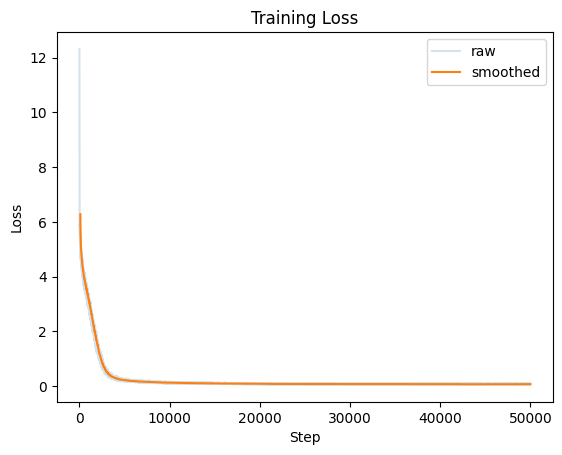

In [139]:
window = 100
smoothed = [
    sum(train_loss[i:i+window]) / window
    for i in range(len(train_loss) - window + 1)
]

import matplotlib.pyplot as plt
plt.plot(train_loss, alpha=0.2, label="raw")
plt.plot(range(window - 1, len(train_loss)), smoothed, label="smoothed")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.show()

In [11]:
import os
import glob
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T

IMAGENETTE_ROOT = "../../datasets/imagenette/imagenette2"

CLASSES = {
      "n01440764": "tench",
      "n02102040": "English springer spaniel",
      "n02979186": "cassette player",
      "n03000684": "chainsaw",
      "n03028079": "church",
      "n03394916": "French horn",
      "n03417042": "garbage truck",
      "n03425413": "gas pump",
      "n03445777": "golf ball",
      "n03888257": "parachute",
}

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

train_tfm = T.Compose([
      T.RandomResizedCrop(224, scale=(0.7, 1.0)),
      T.RandomHorizontalFlip(),
      T.ToTensor(),
      T.Normalize(MEAN, STD),
])

val_tfm = T.Compose([
      T.Resize(256),
      T.CenterCrop(224),
      T.ToTensor(),
      T.Normalize(MEAN, STD),
])


class ImagenetteDataset(Dataset):
    def __init__(self, split, transform):
        self.transform = transform
        self.wnid_to_idx = {wnid: i for i, wnid in enumerate(CLASSES.keys())}
        self.idx_to_name = list(CLASSES.values())

        self.samples = []
        for wnid, idx in self.wnid_to_idx.items():
            pattern = os.path.join(IMAGENETTE_ROOT, split, wnid, "*.JPEG")
            for path in sorted(glob.glob(pattern)):
                self.samples.append((path, idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        img = self.transform(img)
        return img, label


In [12]:
@dataclass
class ConfigParametersViT:
    patch_size: int
    patch_dim: int
    num_patches: int
    num_classes: int
    device: str
    model_dim: int = 256
    num_heads: int = 4
    batch_size: int = 64
    num_blocks: int = 2


In [110]:
#initialize config and model
device = torch.device("cuda")
patch_size = 16     #16 by 16 patches
patch_dim = 768     #3*16*16
num_patches = 196   #14*14 patches (224/16 * 224/16)
num_classes = 10    #no of output classes in imagenette dataset

cfg_vit = ConfigParametersViT(patch_size=patch_size, patch_dim=patch_dim, num_patches=num_patches, num_classes=num_classes, device=device)
opt_cfg_vit = OptimParameters()
vit_model = ViT(cfg_vit)
optimizer_vit = torch.optim.AdamW(vit_model.parameters(), opt_cfg_vit.lr, betas=opt_cfg_vit.betas, eps=opt_cfg_vit.eps)

In [111]:
train_ds = ImagenetteDataset("train", train_tfm)
val_ds   = ImagenetteDataset("val",   val_tfm) 

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=128, shuffle=False, num_workers=2) 

In [112]:
#Pretrain Cutom LLM on Tiny Shakespeare dataset, with BPE Tokenizer
vit_model = vit_model.to(device)
vit_model.train()

step = 0
max_steps = 75*50 #around 50 epochs
train_loss = []

output_dir = "./outputs/vit"

while step < max_steps:
    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        logits, loss = vit_model(x, y)

        optimizer_vit.zero_grad()
        loss.backward()
        optimizer_vit.step()

        train_loss.append(loss.item())
        step += 1
       
        if step % 100 == 0:
            print(f"Step {step} - Loss: {loss.item()}")
            
        if step >= max_steps:
            break
torch.save(
                {"step": step, "model": vit_model.state_dict(), "train_loss": train_loss},                                                                                                            
                os.path.join(output_dir, "vit_final.pt"),     
        )         

Step 100 - Loss: 1.7262420654296875
Step 200 - Loss: 1.567158818244934
Step 300 - Loss: 1.5912243127822876
Step 400 - Loss: 1.148341417312622
Step 500 - Loss: 1.2077083587646484
Step 600 - Loss: 1.191061019897461
Step 700 - Loss: 0.8658748865127563
Step 800 - Loss: 1.0022356510162354
Step 900 - Loss: 0.928794801235199
Step 1000 - Loss: 0.7904589176177979
Step 1100 - Loss: 0.7485611438751221
Step 1200 - Loss: 0.8581920862197876
Step 1300 - Loss: 0.8021274209022522
Step 1400 - Loss: 0.992923378944397
Step 1500 - Loss: 0.9610308408737183
Step 1600 - Loss: 0.7122063636779785
Step 1700 - Loss: 0.9586541056632996
Step 1800 - Loss: 0.8253448009490967
Step 1900 - Loss: 0.8672374486923218
Step 2000 - Loss: 0.8956180810928345
Step 2100 - Loss: 0.7802513241767883
Step 2200 - Loss: 0.7349486351013184
Step 2300 - Loss: 0.6883711814880371
Step 2400 - Loss: 0.8290297985076904
Step 2500 - Loss: 0.7774708271026611
Step 2600 - Loss: 0.6161220073699951
Step 2700 - Loss: 0.5266059041023254
Step 2800 - Los

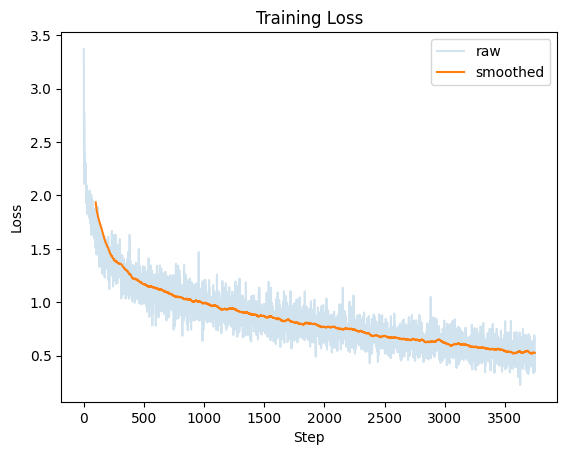

In [116]:
window = 100
smoothed = [
    sum(train_loss[i:i+window]) / window
    for i in range(len(train_loss) - window + 1)
]

import matplotlib.pyplot as plt
plt.plot(train_loss, alpha=0.2, label="raw")
plt.plot(range(window - 1, len(train_loss)), smoothed, label="smoothed")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.show()

In [117]:
def evaluate(model, dataloader, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)

            logits, loss = model(x, y)

            total_loss += loss.item() * x.size(0)

            preds = torch.argmax(logits, dim=1)   # [B]
            total_correct += (preds == y).sum().item()
            total_samples += x.size(0)

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    model.train()
    return avg_loss, accuracy

In [118]:
val_loss, val_acc = evaluate(vit_model, val_loader, device)
print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Val Loss: 0.9932, Val Acc: 0.7032


In [13]:
#Step 3: VLM pretraining 
@dataclass
class ConfigParametersVLM:
    model_dim: int
    vision_model_dim: int
    device: str   
    vision_encoder: Optional[object] = None
    LLM: Optional[object] = None

@dataclass
class OptimParametersVLM:
    lr: float=2e-5
    betas: Tuple=(0.9, 0.99)
    eps: float=1e-8

In [14]:
#create dataloader for VLM pretraining
import json                                               

DATA_DIR = "./data"
                                          
with open(f"{DATA_DIR}/imagenette_qa_train.json") as f:
    train_qa = json.load(f)                                                                                                                                                           
with open(f"{DATA_DIR}/imagenette_qa_val.json") as f:
    val_qa = json.load(f)                                                                                                                                                             
                                                            
print(f"train: {len(train_qa)} samples")   # 42648                                                                                                                                    
print(f"val:   {len(val_qa)} samples")     # 17653  

train: 42648 samples
val:   17653 samples


In [ ]:
from PIL import Image
import json

class ImagenetteQADataset(Dataset):
    def __init__(self, split, tokenizer, transform, max_len=256, data_dir="./data",
                   image_root="../../datasets/imagenette/imagenette2"):
        self.transform = transform
        self.tokenizer = tokenizer
        self.eos = tokenizer.eos_token_id

        if tokenizer.pad_token_id is None:
            tokenizer.pad_token = tokenizer.eos_token
        self.pad_id = tokenizer.pad_token_id

        self.max_len = max_len
        self.root = image_root

        fname = "imagenette_qa_train.json" if split == "train" else "imagenette_qa_val.json"
        with open(os.path.join(data_dir, fname)) as f:
            self.data = json.load(f)
        self.data = self.data[:100]
        
        

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        img = Image.open(os.path.join(self.root, item["image"])).convert("RGB")
        img = self.transform(img)

        q_ids = self.tokenizer(item["question"], add_special_tokens=False)["input_ids"]
        a_ids = self.tokenizer(item["answer"], add_special_tokens=False)["input_ids"] + [self.eos]

        text_ids = q_ids + a_ids
        text_ids = text_ids[:self.max_len]

        text_tokens = torch.tensor(text_ids, dtype=torch.long)

        # next-token targets
        targets = text_tokens.clone()
        targets[:-1] = text_tokens[1:]
        targets[-1] = self.eos

        # mask all question-token positions
        q_len = min(len(q_ids), len(text_tokens))
        targets[:q_len] = -100

        return {
              "image": img,
              "text_tokens": text_tokens,
              "targets": targets,
        }

  #Batch-time padding with a collator:
def imagenette_qa_collate_fn(batch, pad_id):
    images = torch.stack([item["image"] for item in batch], dim=0)

    lengths = [item["text_tokens"].size(0) for item in batch]
    max_len = max(lengths)

    B = len(batch)
    text_tokens = torch.full((B, max_len), pad_id, dtype=torch.long)
    targets = torch.full((B, max_len), -100, dtype=torch.long)
    attention_mask = torch.zeros((B, max_len), dtype=torch.long)

    for i, item in enumerate(batch):
        n = item["text_tokens"].size(0)
        text_tokens[i, :n] = item["text_tokens"]
        targets[i, :n] = item["targets"]
        attention_mask[i, :n] = 1

    return images, text_tokens, attention_mask, targets


In [26]:
train_ds = ImagenetteQADataset("train", tok, val_tfm, max_len=256)
val_ds = ImagenetteQADataset("val", tok, val_tfm, max_len=256)



train_loader = DataLoader(
      train_ds,
      batch_size=32,
      shuffle=True,
      num_workers=2,
      collate_fn=lambda batch: imagenette_qa_collate_fn(batch, train_ds.pad_id),
  )

val_loader = DataLoader(
      val_ds,
      batch_size=32,
      shuffle=False,
      num_workers=2,
      collate_fn=lambda batch: imagenette_qa_collate_fn(batch, val_ds.pad_id),
  )
  
len(train_loader), len(val_loader)

(1333, 552)

In [35]:
tokenizer = AutoTokenizer.from_pretrained("gpt2")
llm_config = ConfigParametersLLM(vocab_size=len(tokenizer), device=device, max_seq_length=512)
llm_model = GPT(llm_config).to(device)
llm_ckpt = torch.load("./outputs/llm/llm_final.pt", map_location=device)
llm_model.load_state_dict(llm_ckpt["model"])
llm_model.eval()

cfg_vit = ConfigParametersViT(patch_size=16, patch_dim=768, num_patches=196, num_classes=10, device=device)
vit_model = ViT(cfg_vit).to(device)
vit_ckpt = torch.load("./outputs/vit/vit_final.pt", map_location=device)
vit_model.load_state_dict(vit_ckpt["model"])
vit_model.eval()

cfg_vlm = ConfigParametersVLM(vision_encoder=vit_model, LLM=llm_model, model_dim=768, vision_model_dim=256, device=device)
vlm_model = VLM(cfg_vlm).to(device)
opt_cfg_vlm = OptimParametersVLM()
optimizer_vlm = torch.optim.AdamW(vlm_model.parameters(), opt_cfg_vlm.lr, betas=opt_cfg_vlm.betas, eps=opt_cfg_vlm.eps)

In [36]:
#Pretrain Cutom VLM 

vlm_model = vlm_model.to(device)
vlm_model.train()

step = 0
max_steps = 7500
train_loss = []

output_dir = "./outputs/vlm"

while step < max_steps:
    for img_tokens, text_tokens, attention_mask, targets in train_loader:
        img_tokens = img_tokens.to(device)
        text_tokens = text_tokens.to(device)
        attention_mask = attention_mask.to(device)
        targets = targets.to(device)
        
        logits, loss = vlm_model(x_img=img_tokens, x_text=text_tokens, targets=targets, attention_mask=attention_mask)

        optimizer_vlm.zero_grad()
        loss.backward()
        optimizer_vlm.step()

        train_loss.append(loss.item())
        step += 1
       
        if step % 100 == 0:
            print(f"Step {step} - Loss: {loss.item()}")
            
        if step >= max_steps:
            break
torch.save(
                {"step": step, "model": vlm_model.state_dict(), "train_loss": train_loss},                                                                                                            
                os.path.join(output_dir, "vlm_final.pt"),     
        )         

Step 100 - Loss: 0.25575944781303406
Step 200 - Loss: 0.10411066561937332
Step 300 - Loss: 0.08942081034183502
Step 400 - Loss: 0.14441266655921936
Step 500 - Loss: 0.12277629971504211
Step 600 - Loss: 0.08642557263374329
Step 700 - Loss: 0.10955749452114105
Step 800 - Loss: 0.17051078379154205
Step 900 - Loss: 0.05581126734614372
Step 1000 - Loss: 0.08869330585002899
Step 1100 - Loss: 0.08089298754930496
Step 1200 - Loss: 0.08695410192012787
Step 1300 - Loss: 0.051577840000391006
Step 1400 - Loss: 0.07383179664611816
Step 1500 - Loss: 0.06576239317655563
Step 1600 - Loss: 0.04962870478630066
Step 1700 - Loss: 0.03568755090236664
Step 1800 - Loss: 0.043829306960105896
Step 1900 - Loss: 0.04448956996202469
Step 2000 - Loss: 0.04001510888338089
Step 2100 - Loss: 0.07290952652692795
Step 2200 - Loss: 0.0360390730202198
Step 2300 - Loss: 0.08053666353225708
Step 2400 - Loss: 0.07255429774522781
Step 2500 - Loss: 0.04443448781967163
Step 2600 - Loss: 0.0504770502448082
Step 2700 - Loss: 0.0

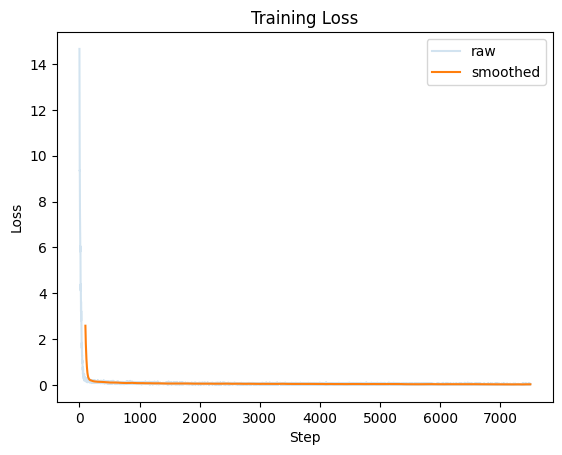

In [38]:
window = 100
smoothed = [
    sum(train_loss[i:i+window]) / window
    for i in range(len(train_loss) - window + 1)
]

import matplotlib.pyplot as plt
plt.plot(train_loss, alpha=0.2, label="raw")
plt.plot(range(window - 1, len(train_loss)), smoothed, label="smoothed")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.show()

In [17]:
def get_item(messages, tokenizer, max_len, transform, root=None):
    content = messages[0]["content"]
    img = None
    text = None

    for item in content:
        if item["type"] == "image":
            image_path = item.get("path") or item.get("url")
            if root is not None and not os.path.isabs(image_path):
                image_path = os.path.join(root, image_path)
            img = Image.open(image_path).convert("RGB")
            img = transform(img)

        elif item["type"] == "text":
            text = item["text"]

    text_ids = tokenizer(text, add_special_tokens=False)["input_ids"][:max_len]
    text_tokens = torch.tensor(text_ids, dtype=torch.long)

    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token
    pad_id = tokenizer.pad_token_id

    text_tokens = text_tokens.unsqueeze(0)                  # [1, T]
    attention_mask = torch.ones_like(text_tokens)          # [1, T]

    return {
        "image": img.unsqueeze(0),                         # [1, C, H, W]
        "text_tokens": text_tokens,
        "attention_mask": attention_mask,
    }


In [18]:
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.eos_token_id = 50256
tokenizer.pad_token = tokenizer.eos_token

device = torch.device("cuda")

llm_config = ConfigParametersLLM(vocab_size=len(tokenizer), device=device, max_seq_length=512)
llm_model = GPT(llm_config).to(device)

vit_config = ConfigParametersViT(patch_size=16, patch_dim=768, num_patches=196, num_classes=10, device=device)
vit_model = ViT(vit_config).to(device)

vlm_config = ConfigParametersVLM(vision_encoder=vit_model, LLM=llm_model, model_dim=768, vision_model_dim=256, device=device)
vlm_model = VLM(vlm_config).to(device)

vlm_ckpt = torch.load("./outputs/vlm/vlm_final.pt", map_location=device)
vlm_model.load_state_dict(vlm_ckpt["model"])
vlm_model.eval()

VLM(
  (vision_encoder): ViT(
    (blocks): ModuleList(
      (0-1): 2 x TransformerBlock(
        (MHSA): MultiHeadAttention(
          (q_proj): Linear()
          (k_proj): Linear()
          (v_proj): Linear()
          (o_proj): Linear()
        )
        (layernorm1): LayerNormalization()
        (layernorm2): LayerNormalization()
        (FFN): Sequential(
          (0): Linear()
          (1): GLU()
          (2): Linear()
        )
      )
    )
    (logit_proj): Linear()
    (x_proj): Linear()
    (pos_emb): Embedding(197, 256)
  )
  (LLM): GPT(
    (blocks): ModuleList(
      (0-1): 2 x TransformerBlock(
        (MHSA): MultiHeadAttention(
          (q_proj): Linear()
          (k_proj): Linear()
          (v_proj): Linear()
          (o_proj): Linear()
        )
        (layernorm1): LayerNormalization()
        (layernorm2): LayerNormalization()
        (FFN): Sequential(
          (0): Linear()
          (1): GLU()
          (2): Linear()
        )
      )
    )
    (logi

In [19]:
from torchvision import transforms as T

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

val_tfm = T.Compose([
      T.Resize(256),
      T.CenterCrop(224),
      T.ToTensor(),
      T.Normalize(MEAN, STD),
])

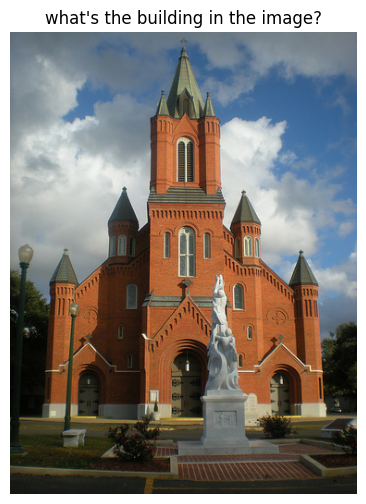

In [23]:
import matplotlib.pyplot as plt

messages = [
      {
          "role": "user",
          "content": [
              {
                  "type": "image",
                  "path": "/home/pensativo/datasets/imagenette/imagenette2/train/n03028079/n03028079_27579.JPEG",
              },
              {
                  "type": "text",
                  "text": "what's the building in the image?",
              },
          ],
      }
  ]



inputs = get_item(messages, tokenizer, max_len=512, transform=val_tfm, root=None)                                                                                                     
image = inputs["image"].to(device)   
attention_mask = inputs["attention_mask"].to(device)                                                                                                                                           
text_tokens = inputs["text_tokens"].to(device)                                                                                                                                        
                                                                                                                                                                                        
with torch.inference_mode():                                                                                                                                                          
    generated_ids = vlm_model.generate(                                                                                                                                               
        image,                                                                                                                                                                        
        text_tokens,                                                                                                                                                                  
        attention_mask,
        max_new_tokens=100,                                                                                                                                                           
        eos_token_id=tokenizer.eos_token_id,
    )

image_path = messages[0]["content"][0]["path"]
prompt_text = messages[0]["content"][1]["text"]

pil_img = Image.open(image_path).convert("RGB")
plt.figure(figsize=(6, 6))
plt.imshow(pil_img)
plt.axis("off")
plt.title(prompt_text)
plt.show()

                                                                                                                                                                                        
print(tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0])
